## Imports

In [ ]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from PIL import Image
from collections import defaultdict
from torchvision import transforms
from torch.utils.data import DataLoader
from pytorch_grad_cam import GradCAMPlusPlus
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image


from iml2_painting_style.model_resnet import ArtistStyleClassifier
from iml2_painting_style.model_efficientnet import EfficientNetClassifier
from iml2_painting_style.simclr_model import SimCLR, LinearClassifier
from iml2_painting_style.vae import ConvVAE
from iml2_painting_style.dataset import PaintingStyleDataset
from iml2_painting_style.transforms import get_transforms
from iml2_painting_style.checkpoints import load_checkpoint
from iml2_painting_style.utils import set_seed, get_device

set_seed(1)
device = get_device()
print(f"Using device: {device}")


Using device: mps


## Configuration

In [10]:
IMAGE_SIZE = 128
LATENT_DIM = 32
NUM_CLASSES = 8
DATA_ROOT = PROJECT_ROOT / "data"
CHECKPOINTS_DIR = PROJECT_ROOT / "checkpoints"

RESNET18_BEST = CHECKPOINTS_DIR / "resnet18_best_checkpoint.pth"
EFFICIENTNET_BEST = CHECKPOINTS_DIR / "efficientnet_best_checkpoint.pth"
SSL_BEST = CHECKPOINTS_DIR / "ft_best.pt"
VAE_BEST = CHECKPOINTS_DIR / "vae_best.pt"

img_mean = [0.5224, 0.4805, 0.4183]
img_std = [0.2556, 0.2468, 0.2495]


## Load Models

In [ ]:
# ResNet18
model_resnet, _, _, _, _, _ = load_checkpoint(
    RESNET18_BEST,
    ArtistStyleClassifier(num_classes=NUM_CLASSES, pretrained=False).to(device),
    optimizer=None,
    map_location=str(device),
)
model_resnet.eval()

# EfficientNet
model_eff, _, _, _, _, _ = load_checkpoint(
    EFFICIENTNET_BEST,
    EfficientNetClassifier(num_classes=NUM_CLASSES, pretrained=False).to(device),
    optimizer=None,
    map_location=str(device),
)
model_eff.eval()

# SimCLR
class SSLWrapper(nn.Module):
    def __init__(self, backbone, classifier):
        super().__init__()
        self.backbone = backbone
        self.classifier = classifier
    def forward(self, x):
        return self.classifier(self.backbone(x))

_ssl_base = SimCLR(pretrained=False)
_ssl_combined, _, _, _, _, _ = load_checkpoint(
    SSL_BEST,
    torch.nn.ModuleDict({
        'backbone': _ssl_base.backbone,
        'classifier': LinearClassifier(_ssl_base.feature_dim, NUM_CLASSES),
    }).to(device),
    optimizer=None,
    map_location=str(device),
)
model_ssl = SSLWrapper(_ssl_combined['backbone'], _ssl_combined['classifier']).to(device)
model_ssl.eval()

# VAE 
class VAEClassifierWrapper(nn.Module):
    def __init__(self, vae, prototypes):
        super().__init__()
        self.encoder = vae.encoder
        self.fc_mu = vae.fc_mu
        self.prototypes = nn.Parameter(prototypes, requires_grad=False)
    def forward(self, x):
        h = self.encoder(x).flatten(1)
        mu = self.fc_mu(h)
        mu_norm = F.normalize(mu, dim=1)
        proto_norm = F.normalize(self.prototypes, dim=1)
        return mu_norm @ proto_norm.T

_vae_base, _, _, _, _, _ = load_checkpoint(
    VAE_BEST,
    ConvVAE(latent_dim=LATENT_DIM, image_size=IMAGE_SIZE).to(device),
    optimizer=None,
    map_location=str(device),
)
_vae_base.eval()

vae_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
])
test_raw_vae = PaintingStyleDataset(DATA_ROOT / "test", transform=vae_transform)
test_vae_loader = DataLoader(test_raw_vae, batch_size=32, shuffle=False, num_workers=0)

all_mu, all_lbls = [], []
with torch.no_grad():
    for imgs, lbls in test_vae_loader:
        mu, _ = _vae_base.encode(imgs.to(device))
        all_mu.append(mu.cpu())
        all_lbls.extend(lbls.numpy())
all_mu = torch.cat(all_mu)
all_lbls = np.array(all_lbls)

prototypes = torch.stack([
    all_mu[all_lbls == c].mean(0) for c in range(NUM_CLASSES)
]).to(device)

model_vae = VAEClassifierWrapper(_vae_base, prototypes).to(device)
model_vae.eval()

print("All four models loaded.")


All four models loaded.


## Target Layers

In [12]:
target_resnet = [model_resnet.backbone.layer4[-1]]
target_eff = [model_eff.backbone.features[-1][0]]
target_ssl = [model_ssl.backbone.layer4[-1]]
target_vae = [model_vae.encoder[-2]]

## Select Test Images

In [ ]:
test_raw = PaintingStyleDataset(DATA_ROOT / "test", transform=None)
classes = test_raw.classes

class_samples = defaultdict(list)
for path, label in test_raw.samples:
    class_samples[label].append(path)

selected_paths = [class_samples[i][0] for i in range(len(classes))]
selected_labels = list(range(len(classes)))

print("Selected images:")
for path, label in zip(selected_paths, selected_labels):
    print(f"  [{classes[label]}] {Path(path).name}")


Selected images:
  [ArtDeco] tamara-de-lempicka_the-communicant-1928.jpg
  [Cubism] paul-cezanne_bibemus-quarry.jpg
  [Impressionism] claude-monet_the-japanese-bridge.jpg
  [Japonism] katsushika-hokusai_shichiri-beach-in-sagami-province.jpg
  [Naturalism] charles-tunnicliffe_curlews-alighting.jpg
  [Rococo] jean-baptiste-simeon-chardin_still-life-with-cat-and-rayfish.jpg
  [cartoon] download (1).jpg
  [photo] 004527.jpg


## Helper Functions

In [14]:
preprocess = get_transforms("test", IMAGE_SIZE)
vae_preprocess = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
])

def load_image(path):
    img = Image.open(path).convert("RGB")
    img_resized = img.resize((IMAGE_SIZE, IMAGE_SIZE))
    rgb = np.array(img_resized, dtype=np.float32) / 255.0
    tensor = preprocess(img).unsqueeze(0).to(device)
    vae_tensor = vae_preprocess(img).unsqueeze(0).to(device)
    return tensor, vae_tensor, rgb

def get_cam(model, target_layers, tensor, label):
    cam = GradCAMPlusPlus(model=model, target_layers=target_layers)
    grayscale = cam(input_tensor=tensor,
                   targets=[ClassifierOutputTarget(label)])
    return grayscale[0]


## Grad-CAM++ Comparison

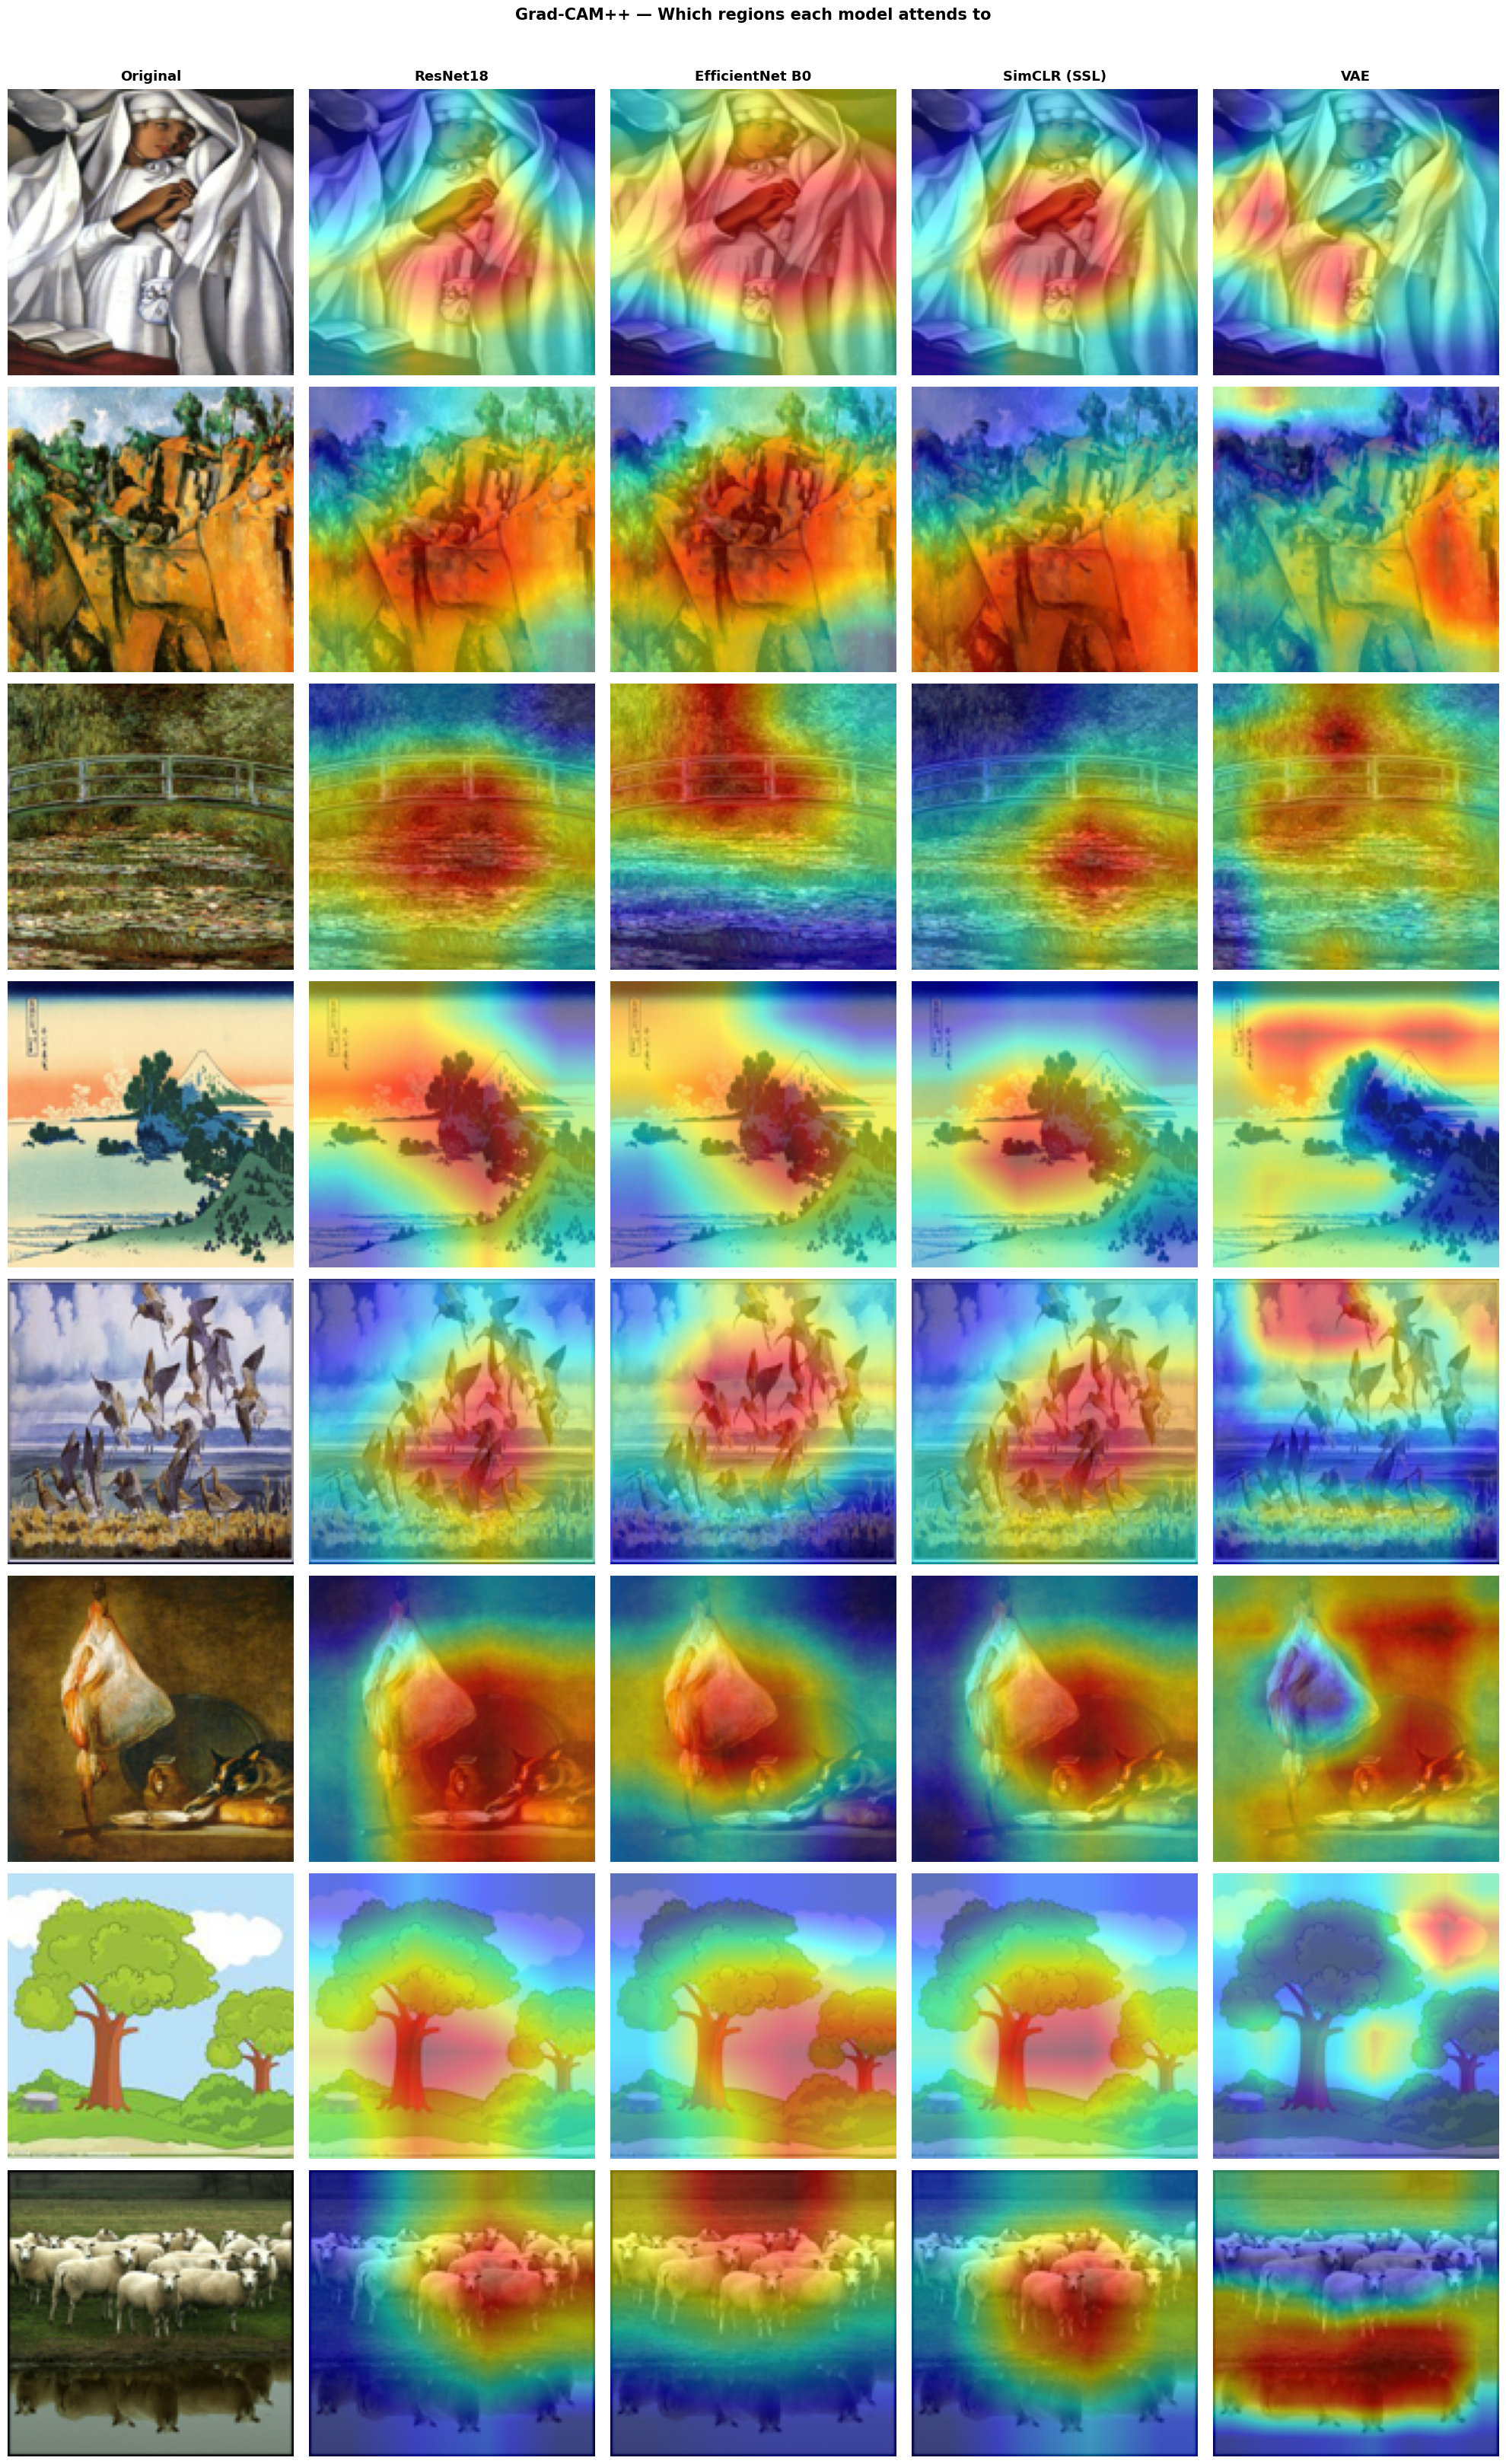

In [15]:
n = len(selected_paths)
fig, axes = plt.subplots(n, 5, figsize=(20, 4 * n))

col_titles = ["Original", "ResNet18", "EfficientNet B0", "SimCLR (SSL)", "VAE"]
for ax, title in zip(axes[0], col_titles):
    ax.set_title(title, fontsize=13, fontweight="bold", pad=8)

for row, (path, label) in enumerate(zip(selected_paths, selected_labels)):
    tensor, vae_tensor, rgb = load_image(path)

    cam_resnet = get_cam(model_resnet, target_resnet, tensor, label)
    cam_eff = get_cam(model_eff, target_eff, tensor, label)
    cam_ssl = get_cam(model_ssl, target_ssl, tensor, label)
    cam_vae = get_cam(model_vae, target_vae, vae_tensor, label)

    overlays = [
        rgb,
        show_cam_on_image(rgb, cam_resnet, use_rgb=True).astype(np.float32) / 255.0,
        show_cam_on_image(rgb, cam_eff, use_rgb=True).astype(np.float32) / 255.0,
        show_cam_on_image(rgb, cam_ssl, use_rgb=True).astype(np.float32) / 255.0,
        show_cam_on_image(rgb, cam_vae, use_rgb=True).astype(np.float32) / 255.0,
    ]

    for col, img in enumerate(overlays):
        axes[row, col].imshow(img)
        axes[row, col].axis("off")
        if col == 0:
            axes[row, col].set_ylabel(classes[label], fontsize=11,
                                      rotation=0, labelpad=60, va="center")

plt.suptitle("Grad-CAM++ — Which regions each model attends to",
             fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "reports" / "xai_gradcam.png", dpi=150, bbox_inches="tight")
plt.show()
